# Natural Language Processing 2

In [1]:
 import pandas as pd

In [2]:
df = pd.read_csv('spam.csv' , encoding = 'iso-8859-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
import seaborn as sns

<Axes: xlabel='v1', ylabel='count'>

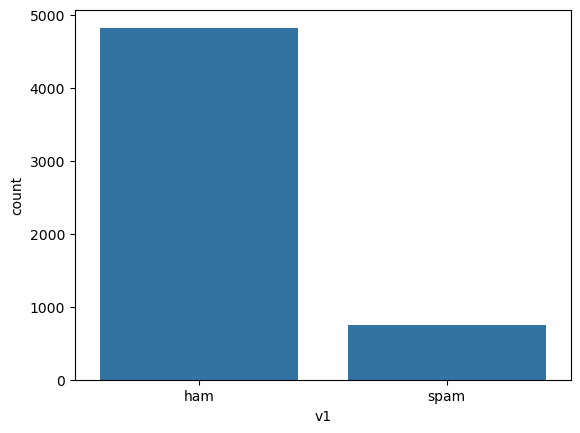

In [5]:
sns.countplot(x = df['v1'])

In [6]:
df['v1'].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'], axis = 1 , inplace = True )

In [8]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.columns = ['class','text']

In [10]:
df.head()

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# pip install neattext

In [12]:
import neattext as nfx

In [13]:
df.head()

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df['text'] = df['text'].apply(nfx.normalize)

In [15]:
df.head()

,class,text
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


In [16]:
df.shape

(5572, 2)

In [17]:
s = ' '.join(df['text']) # tüm sütunlarda ki metinleri tek bir metin yapar.

In [ ]:
s

In [19]:
s = nfx.clean_text(s)

In [20]:
s = nfx.remove_emails(s)

In [21]:
s = nfx.remove_special_characters(s)

In [ ]:
s

In [23]:
s = nfx.TextFrame(s) 

In [24]:
s.describe()

Key      Value          
Length  : 264774         
vowels  : 78171          
consonants: 138955         
stopwords: 2471           
punctuations: 0              
special_char: 0              
tokens(whitespace): 45164          
tokens(words): 45164          


In [25]:
s.length

264774

In [26]:
s.readability() # kitabın kime uygun olduğunu söyler . çocuk mu yetişkin mi ...

{'automated readability': 23829.24233394195, 'description': None}

In [ ]:
# Gutenberg kitap kütüphanesini denedik

In [27]:
import nltk

In [28]:
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\gutenberg.zip.


True

In [30]:
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [31]:
seyhpir = nltk.corpus.gutenberg.raw('shakespeare-hamlet.txt')

In [ ]:
seyhpir

In [33]:
seyhpir = nfx.TextFrame(seyhpir)

In [34]:
seyhpir.readability()

{'automated readability': 12.990613823318782,
 'description': '18-24 years (College student)'}

In [36]:
# Gutenberg kitap kütüphanesini denedik bitti

In [37]:
df['text']=df['text'].str.lower() #kucuk harfe cevir
df['text']=df['text'].str.replace('[^\w\s]','',regex=True) #noktalama isaretlerini kadir
df['text']=df['text'].str.replace('\d+','',regex=True) # rakamlari kaldir
df['text']=df['text'].str.replace('\n','',regex=True) #satir sonlarini kaldir
df['text']=df['text'].str.replace('\r','',regex=True) # enter lari kaldir

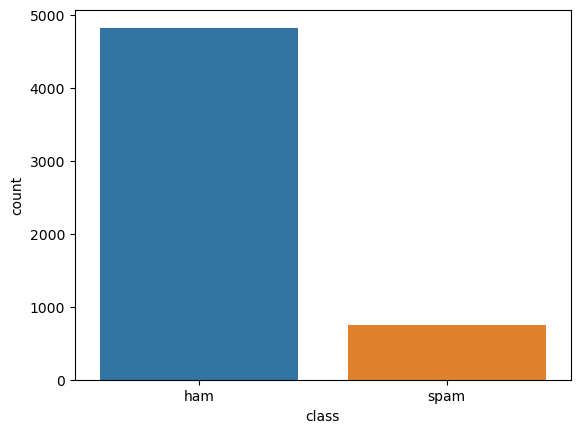

In [38]:
sns.countplot(x=df['class'], hue=df['class']);

In [41]:
# imbalanced Smote Sentetic Data - simulasyon data

In [42]:
x = df['text']
y = df['class']

In [43]:
# poe den alınan sentetic data oluşturma kodu
'''
# Create a sample imbalanced dataset
X, y = make_classification(n_classes=2, class_sep=2,
                           weights=[0.9, 0.1], n_informative=3,
                           n_redundant=1, flip_y=0,
                           n_features=20, n_clusters_per_class=1,
                           n_samples=1000, random_state=42)

print("Original dataset shape:", Counter(y))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))
'''

'\n# Create a sample imbalanced dataset\nX, y = make_classification(n_classes=2, class_sep=2,\n                           weights=[0.9, 0.1], n_informative=3,\n                           n_redundant=1, flip_y=0,\n                           n_features=20, n_clusters_per_class=1,\n                           n_samples=1000, random_state=42)\n\nprint("Original dataset shape:", Counter(y))\n\n# Apply SMOTE\nsmote = SMOTE(random_state=42)\nX_resampled, y_resampled = smote.fit_resample(X, y)\n\nprint("Resampled dataset shape:", Counter(y_resampled))\n'

In [44]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
# pipeline yapilacak işleri sıralı yapar ve boyut problemini çözer

In [50]:
from sklearn.pipeline import Pipeline

In [51]:
clf=Pipeline([('tfidf',TfidfVectorizer()),('Classifier',RandomForestClassifier())])

In [53]:
from sklearn.model_selection import train_test_split

In [56]:
x_train , x_test , y_train, y_test = train_test_split(x, y, random_state= 42 , test_size = 0.2)

In [58]:
clf.fit(x_train , y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('Classifier', RandomForestClassifier())])

In [59]:
tahmin = clf.predict(x_test)

In [60]:
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix

In [61]:
accuracy_score(tahmin , y_test)

0.9695067264573991

In [62]:
print(classification_report(tahmin, y_test))

              precision    recall  f1-score   support

         ham       1.00      0.97      0.98       999
        spam       0.77      1.00      0.87       116

    accuracy                           0.97      1115
   macro avg       0.89      0.98      0.93      1115
weighted avg       0.98      0.97      0.97      1115

